# Semester 4 Coding Portfolio Part 6: Intermediate Classification

This notebook covers the following topics:
 - Gradient Descent
 - Training linear and logistic regression from scratch
 - Neural Networks and backpropagation

This notebook is expected to take around 20 hours to complete:
 - 4 hours for the formative part
 - 6 hours of self-study on the topics covered by this notebook
 - 10 hours for the summative part of this notebook

Like all notebooks in this portfolio, it is split into two sections:
 - Formative 
 - Summative

<b>Formative section</b><br>
Simply complete the given functions such that they pass the automated tests. This part is graded Pass/Fail; you must get 100% correct!
You can submit your notebook through Canvas as often as you like. Make sure to start doing so early to insure that your code passes all tests!
You may ask for help from fellow students and TAs on this section, and solutions might be provided later on.

<b>Summative section</b><br>
In this section, you are asked to do original work with little guidance, based on the skills you learned in the formative part (as well as lectures and workshops).
This section is graded not just on passing automated tests, but also on quality, originality, and effort (see assessment criteria in the assignment description).

In [24]:
# TODO: Please enter your student number here
STUDENT_NUMBER = 0

# Formative Section
Please do not add additional cells to this section, and do not delete given code. Simply fill out the code or answer questions in the given cells.

In [25]:
# Imports
import math

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Part 1: Linear regression
Let's generate a dataset about student attendance and grades. 

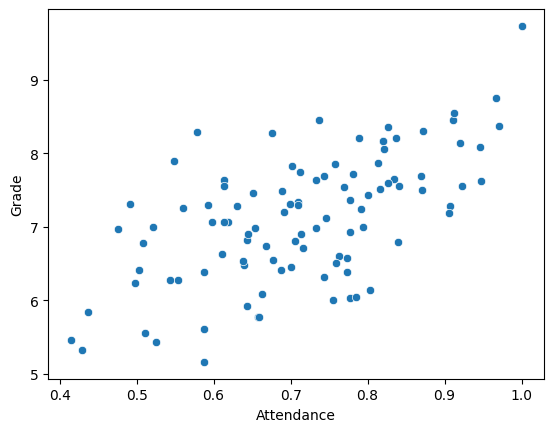

In [26]:
np.random.seed(42)
# Generate array, first dimension Attendance, second Grade
# We want there to be correlation between the two, so create a covariance matrix
cov = np.array([
    [1,0.7],
    [0.7,1]
])
scores = stats.multivariate_normal.rvs(mean = [0,7], cov=cov, size = 100)
data = pd.DataFrame(data = scores, columns = ["Attendance", "Grade"])
# Set mean and std of Attendance
data['Attendance'] = data['Attendance'].apply(lambda x: x * 0.15 + 0.7)
# Truncate scores
data['Attendance'] = data['Attendance'].apply(lambda x: x if x >= 0 else 0)
data['Attendance'] = data['Attendance'].apply(lambda x: x if x <= 1 else 1)
data['Grade'] = data['Grade'].apply(lambda x: x if x >= 0 else 0)
data['Grade'] = data['Grade'].apply(lambda x: x if x <= 10 else 10)

#plt.scatter(data['Attendance'], data['Grade'])
ax = sns.scatterplot(data, x='Attendance', y='Grade')

We'll manually do a linear regression. First, we will create the cost function. Implement:
$$ J(\mathrm{\beta}_{0}, \mathrm{\beta}_{1})=\sum_{i=1}^{n}(y_{i}-\hat{y}_{i})^2 $$

110.41288200825313


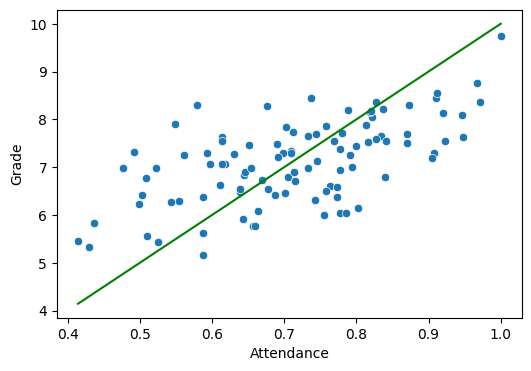

In [27]:

# TODO 1: Implement this function

#. Your solution here ...
def compute_cost(y: np.array, y_pred: np.array) -> np.array:
    """ Calculates the sum of square errors (SSE) between observed and predicted y values.

    Args:
        y: The observed grades.
        y_pred: The predicted grades.
    """

    m = y.shape[0] # Get the number of samples from y array
    cost = 0  # Initialize cost to zero

    # Loop over all samples
    for i in range(m):
        cost = cost + (y_pred[i] - y[i])**2  # Add squared difference for each sample
    return cost

# Let's try out our cost function on a made-up linear prediction:
intercept = 0
slope = 10
grade_pred = intercept + data['Attendance'] * slope
print(compute_cost(data['Grade'], grade_pred))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
p1 = sns.scatterplot(data, x='Attendance', y='Grade', ax=ax)
p2 = sns.lineplot(x=data['Attendance'], y=grade_pred, color='g', ax=ax)

Play around with the slope and intercept in the made-up linear function above by slightly changing the values, and see whether you can find parameters which result in a lower cost.

Next, we want to find the best parameters with the lowest cost. We could try random parameters until we find a low enough cost, or we could do a grid search to find the best parameters to some predefined granularity. But we're better than that, so let's implement gradient descent.
First, we calculate the gradients for slope and intercept respectively:
$$ \frac{\Delta J(\beta_{0},\beta_{1})}{\Delta \beta_{1}} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_{i}-y_{i})x_{i} $$

$$ \frac{\Delta J(\beta_{0},\beta_{1})}{\Delta \beta_{0}} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_{i}-y_{i}) $$

Remember that our function for linear regression is:
$$ \hat{y}=\mathrm{\beta}_{0}+\mathrm{\beta}_{1}*x $$

In [28]:
# TODO 2: Implement this function


#. Your solution here ...
def compute_gradient(x: np.array, y: np.array, b0: float, b1: float): 
    """
    Computes the gradient for linear regression 
    Args:
      x: The observed attendance.
      y: The observed grades.
      b0, b1: model parameters (intercept and slope)
    Returns
      dj_db0: The gradient of b0
      dj_db1: The gradient of b1
     """
    
    # Compute predicted values using the linear equation: y = b0 + b1 * x
    y_pred = b0 + b1 * x
    # Get the number of samples for averaging the gradient
    n = len(x)
    
    # Calculate gradient for intercept (b0): mean of (predicted - actual)
    dj_db0 = (1/n) * np.sum(y_pred - y)
    # Calculate gradient for slope (b1): mean of (predicted - actual) * x
    dj_db1 = (1/n) * np.sum((y_pred - y) * x)
    
    # Return the two gradient components as a tuple
    return dj_db0, dj_db1

# Let's test our function on the parameters we guessed above:
delta_b0, delta_b1 = compute_gradient(data['Attendance'], data['Grade'], intercept, slope)
print(f'For our intercept {intercept} the gradient is {delta_b0}.\nFor our slope of {slope} the gradient is {delta_b1}.')

For our intercept 0 the gradient is 0.018876052628422464.
For our slope of 10 the gradient is 0.11923865357829837.


Gradient descent improved your parameters by subtracting the gradient, or a fraction of the gradient from your parameters. Let's see whether one step of gradient descent improves our model.

In [29]:
# One more time, calculate the cost for manually guessed parameters:
grade_pred = intercept + data['Attendance'] * slope
print(f'Initial cost: {compute_cost(data["Grade"], grade_pred)}')

# Calculate the gradient:
delta_b0, delta_b1 = compute_gradient(data['Attendance'], data['Grade'], intercept, slope)
# Subtract the gradient
intercept = intercept - delta_b0
slope = slope - delta_b1
# Calculate new predictions with these new parameters
grade_pred = intercept + data['Attendance'] * slope
# New cost
print(f'Updated cost: {compute_cost(data["Grade"], grade_pred)}')
print(f'Updated function: y = {intercept:.3f} + {slope:.3f}*x')


Initial cost: 110.41288200825313
Updated cost: 108.604544013136
Updated function: y = -0.019 + 9.881*x


Did the cost decrease? Congratulations, you just improved your model. But why stop there? Hit that run button a few more times. You'll see the cost decrease more and more, as your model gets more accurate.
Now, the next step would be to write a function which does this repeatedly until the function converges at the global minimum. But you know how to do that, so now with our knowledge of gradients refreshed, let's move on to classification.

## Part 2: Logistic Regression
Now let's do the same for logistic regression. I promise we'll get to neural nets right after that.<br>
How? See here: https://www.baeldung.com/cs/gradient-descent-logistic-regression<br>
A nice explanation is also found in this read-along notebooks:<br>
https://github.com/marinavillaschi/ML-AndrewNg/blob/main/C1-Supervised%20ML_Regression%20and%20Classification/Week%203/C1_W3_Lab04_LogisticLoss_Soln.ipynb<br>
https://github.com/marinavillaschi/ML-AndrewNg/blob/main/C1-Supervised%20ML_Regression%20and%20Classification/Week%203/C1_W3_Lab06_Gradient_Descent_Soln.ipynb<br>
Since we are now doing classification instead of regression, let's generate some classes for our students and split them into good students and great students.

In [30]:
data['Class'] = data['Grade'].apply(lambda x: 1 if x > 7.5 else 0)

First, implement the cost function for logistic regression.

2.2042909115834366


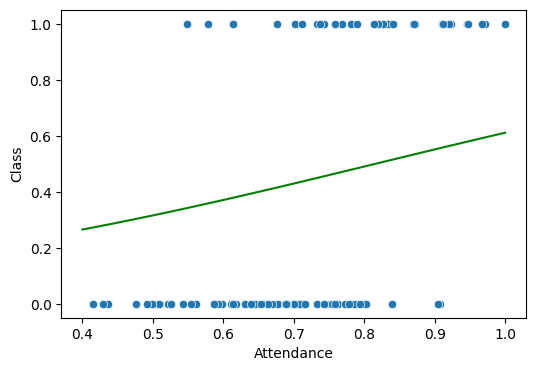

In [31]:
# TODO 3: Implement this function

#. Your solution here ...
def compute_cost_logistic(y: np.array, y_pred: np.array) -> np.array:
    """ Calculates the cost between observed and predicted y values.

    Args:
        y: The observed grades.
        y_pred: The predicted grades.
    """
    m = y.shape[0] # Get number of samples from y array
    cost = 0 # Initialize cost to zero

    # Loop over all samples
    for i in range(m):
        cost = cost + -1/m * np.sum(y[i] * np.log(y_pred[i]) + (1-y[i]) * (np.log(1-y_pred[i])))
    return cost

# Let's try out our cost function on made-up coefficients:
intercept = -2
slope = 2.45
grade_pred = data['Attendance'].apply(lambda x: 1 / (1 + math.exp(-(intercept + x * slope))))
print(compute_cost_logistic(data['Grade'], grade_pred))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
p1 = sns.scatterplot(data, x='Attendance', y='Class', ax=ax)
x = np.linspace(0.4, 1)
y = [1 / (1 + math.exp(-(intercept + xi * slope))) for xi in x]
p2 = sns.lineplot(x=x, y=y, color='g', ax=ax)

Now the gradients:

In [32]:
# TODO 4: Implement this function

#. Your solution here ...
def compute_gradient_logistic(x: np.array, y: np.array, b0: float, b1: float): 
    """
    Computes the gradient for logistic regression 
    Args:
      x: The observed attendance.
      y: The observed grades.
      b0, b1: model parameters (intercept and slope)
    Returns
      dj_db0: The gradient of b0
      dj_db1: The gradient of b1
     """
    # Define sigmoid function
    def sigmoid(x):
      # Compute sigmoid, split for stability
      return np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x)))

    m = x.shape[0] # Get number of samples
    dj_db1 = 0  # Initialize gradient for b1
    dj_db0 = 0  # Initialize gradient for b0
    
    # Loop over samples
    for i in range(m):
        f_wb0_i = sigmoid(np.dot(x[i],b1) + b0) # Predict probability for sample i
        err_i  = f_wb0_i  - y[i] # Calculate error for sample i
        dj_db1 = dj_db1 + err_i * x[i] # Add to b1 gradient: error * x[i]
        dj_db0 = dj_db0 + err_i  # Add to b0 gradient: just error
    dj_db1 = dj_db1/m # Average b1 gradient
    dj_db0 = dj_db0/m # Average b0 gradient

    return dj_db0, dj_db1


# Let's test our function on the parameters we guessed above:
delta_b0, delta_b1 = compute_gradient_logistic(data['Attendance'], data['Class'], intercept, slope)
print(f'For our intercept {intercept} the gradient is {delta_b0}.\nFor our slope of {slope} the gradient is {delta_b1}.')

For our intercept -2 the gradient is 0.07917847209023042.
For our slope of 2.45 the gradient is 0.032663398547392634.


And now we tune our parameters

In [33]:
# One more time, calculate the cost for manually guessed parameters:
grade_pred = data['Attendance'].apply(lambda x: 1 / (1 + math.exp(-(intercept + x * slope))))
print(f'Initial cost: {compute_cost_logistic(data["Class"], grade_pred)}')
print(f'Initial accuracy: {accuracy_score(data['Class'], round(grade_pred))}')

# Calculate the gradient:
delta_b0, delta_b1 = compute_gradient_logistic(data['Attendance'], data['Class'], intercept, slope)
# Subtract the gradient
intercept = intercept - delta_b0
slope = slope - delta_b1
# Calculate new predictions with these new parameters
grade_pred = data['Attendance'].apply(lambda x: 1 / (1 + math.exp(-(intercept + x * slope))))
# New cost
print(f'Updated cost: {compute_cost_logistic(data["Class"], grade_pred)}')
print(f'Updated accuracy: {accuracy_score(data['Class'], round(grade_pred))}')
print(f'Updated function: y = {intercept:.3f} + {slope:.3f}*x')

Initial cost: 0.5948409039422216
Initial accuracy: 0.81
Updated cost: 0.588768127753699
Updated accuracy: 0.74
Updated function: y = -2.079 + 2.417*x


## Part 3: Backpropagation
In order to back-propagate, we first have to forward-propagate. So let's quickly build a neural net from scratch:

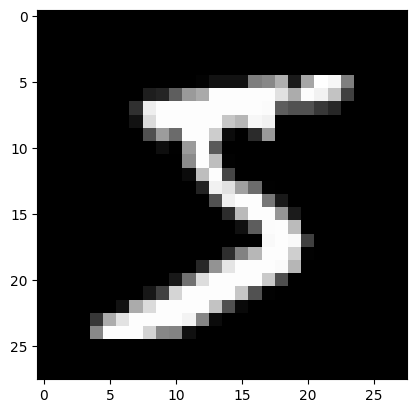

In [34]:
# First we download the mnist dataset. You are familiar with this from the CNN workshop last semester.
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', return_X_y=True) 
X = np.array(X)
y = np.array(y)
test_img = X[0].reshape(28,28)
plt.imshow(test_img, cmap='gray')


The MNIST dataset consists of 70000 28x28 pixel images of handwritten numbers, including the label which is the number the image displays.<br>
Classifying this data is an image-recognition task, which is best done using CNNs. But because I am no sadist, we will attempt this with a good old simple ANN.<br>
In this section, we will build and train a simple neural network: 784 input nodes, two 16 node hidden layers with sigmoid activations, and 10 output nodes with a softmax activation.<br>
Let's first get a few essential components out of the way before we start building our network.

In [35]:
# TODO 5: Implement a sigmoid function which can handle arrays.

#. Your solution here ...
def sigmoid(x: np.array) -> np.array:
  # Numerically stable sigmoid function based on
  # http://timvieira.github.io/blog/post/2014/02/11/exp-normalize-trick/
  
  # Limit x to avoid overflow in exp
  x = np.clip(x, -500, 500) # We get an overflow warning without this
  
  # Compute sigmoid, split for stability
  return np.where(
    x >= 0, #check if x is non-negative
    1 / (1 + np.exp(-x)),
    np.exp(x) / (1 + np.exp(x)) 
  )

print(f'sigmoid(3) should return 0.9525741268224334 and returns: {sigmoid(3)}')
print(f'sigmoid([3,4,5]) should return [0.95257413 0.98201379 0.99330715] and returns: {sigmoid([3,4,5])}')
print(f'sigmoid([-10,0,10]) should return [4.53978687e-05 5.00000000e-01 9.99954602e-01] and returns: {sigmoid([-10,0,10])}')

sigmoid(3) should return 0.9525741268224334 and returns: 0.9525741268224334
sigmoid([3,4,5]) should return [0.95257413 0.98201379 0.99330715] and returns: [0.95257413 0.98201379 0.99330715]
sigmoid([-10,0,10]) should return [4.53978687e-05 5.00000000e-01 9.99954602e-01] and returns: [4.53978687e-05 5.00000000e-01 9.99954602e-01]


In [36]:
# TODO 6: Implement a softmax function

#. Your solution here ...
def softmax(x):
    b = x.max()
    y = np.exp(x - b)
    return y / y.sum()

print(f'softmax([3,4,5]) should return [0.09003057 0.24472847 0.66524096] and returns: {softmax(np.array([3,4,5]))}')
print(f'softmax([-10,0,10]) should return [2.06106005e-09 4.53978686e-05 9.99954600e-01] and returns: {softmax(np.array([-10,0,10]))}')

softmax([3,4,5]) should return [0.09003057 0.24472847 0.66524096] and returns: [0.09003057 0.24472847 0.66524096]
softmax([-10,0,10]) should return [2.06106005e-09 4.53978686e-05 9.99954600e-01] and returns: [2.06106005e-09 4.53978686e-05 9.99954600e-01]


In [37]:
def one_hot_encode(x: int) -> np.array:
  # x: integer to convert to one hot encoding
  result = np.zeros(10)
  result[int(x)] = 1
  return result


 # TODO 7: Implement cross entropy loss

#. Your solution here ...
def cross_entropy_loss(y, y_pred):
  return -np.sum(y * np.log(y_pred))

print(f'One hot encoding turns 7 into {one_hot_encode(7)}')
print(f'cross_entropy_loss([1,0,0], [0.6,0.2,0.2]) should return 0.5108256237659907 and returns: {cross_entropy_loss([1,0,0], [0.6,0.2,0.2])}')
print(f'cross_entropy_loss([0,0,0,1,0], [0.1,0.2,0.3,0.3,0.1]) should return 1.2039728043259361 and returns: {cross_entropy_loss([0,0,0,1,0], [0.1,0.2,0.3,0.3,0.1])}')

One hot encoding turns 7 into [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
cross_entropy_loss([1,0,0], [0.6,0.2,0.2]) should return 0.5108256237659907 and returns: 0.5108256237659907
cross_entropy_loss([0,0,0,1,0], [0.1,0.2,0.3,0.3,0.1]) should return 1.2039728043259361 and returns: 1.2039728043259361


Now we have our activation functions and loss function defined, so let's start building our network.<br>
Neural networks are usually initiallized with random weights, so lets generate some.<br>
To repeat, our neural net has the following structure: 784-16-16-10<br>
The weights for each layer should by matrix of shape n_nodes * n_nodes_previous_layer

In [38]:
# TODO 8: Initialize weights of each layer with a normal distribution ofd mean 0 and std of 1

rng = np.random.default_rng(42)

#. Your solution here ...
weights = [
    rng.normal(0, 1, (16, 784)),  # First layer: 16 nodes × 784 inputs
    rng.normal(0, 1, (16, 16)),   # Second layer: 16 nodes × 16 previous nodes
    rng.normal(0, 1, (10, 16))    # Output layer: 10 nodes × 16 previous nodes
]

biases = [np.zeros(16), np.zeros(16), np.zeros(10)]

Implement your 784-16-16-10 neural net. Remember that the two hidden layers use sigmoid for activation, and the final layer uses softmax.

In [39]:
# TODO 9: Implement feeding forward a single sample through your neural net

#. Your solution here ...
def feed_forward_sample(sample: np.array, weights, biases):
    """ Feeds a sample forward through the neural network.
    Parameters:
      sample: 1D numpy array. The input sample (an MNIST digit).
    Returns: 1D numpy array. The prediction values for the digits 0-9
    """
    # Layer 1: Compute weighted sum for first layer:
    z1 = np.dot(weights[0], sample) + biases[0]
    a1 = sigmoid(z1)
    
    # Layer 2: # Compute weighted sum for second layer:
    z2 = np.dot(weights[1], a1) + biases[1]
    a2 = sigmoid(z2)
    
    # Output layer
    z3 = np.dot(weights[2], a2) + biases[2]
    a3 = softmax(z3)
    
    return a3

def calculate_loss(y: int, y_pred: np.array):

  # Calculate loss
  one_hot_y = one_hot_encode(y)
  loss = cross_entropy_loss(one_hot_y, y_pred)
  
  return loss

# Test this function on the first sample
y_pred = feed_forward_sample(X[0,:], weights, biases)
loss = calculate_loss(y[0], y_pred)

print(loss)

7.284579409355388


Now lets use the first 1000 images as our test set (for computation time puprposes) and run the whole set!

In [40]:
# TODO 10: Forward a whole batch of samples.

#. Your solution here ...
def feed_forward_batch(X, weights, biases):
    # Layer 1
    z1 = np.dot(X, weights[0].T) + biases[0]
    a1 = sigmoid(z1)
    
    # Layer 2
    z2 = np.dot(a1, weights[1].T) + biases[1]
    a2 = sigmoid(z2)
    
    # Output layer
    z3 = np.dot(a2, weights[2].T) + biases[2]
    a3 = np.apply_along_axis(softmax, 1, z3)
    
    return a3

def calculate_cost(y, y_pred):
    # Calculate the average loss over a series of predictions
    losses = [calculate_loss(y[i], y_pred[i,:]) for i in range(len(y))]
    return np.mean(losses)


X_test = X[:1000,:]
y_test = y[:1000]

y_pred = feed_forward_batch(X_test, weights, biases)
print(f'Average loss: {calculate_cost(y_test, y_pred):.2f}')

# Let's see our accuracy so far
def calculate_accuracy(y, y_pred):
    # One hot encode labels and predictions
    one_hot_y = np.array([one_hot_encode(yi) for yi in y])
    one_hot_y_pred = np.zeros_like(y_pred)
    for i in range(y_pred.shape[0]):
        one_hot_y_pred[i,np.argmax(one_hot_y_pred[i,:])] = 1
    return np.sum(one_hot_y * one_hot_y_pred) / y.shape[0] * 100

print(f'Accuracy: {calculate_accuracy(y_test, y_pred):.2f}%')

Average loss: 6.17
Accuracy: 9.70%


Given that there are 10 possible digits, guessing randomly should result in an accuracy of 10%. So our randomly initialized neural net should give a similar accuracy.<br>
Now there is only one super simple step left: Backpropagate and update the weights to train your model.<br>
Hint: There is data you need to cache from forward propagation in order to calculate gradients during backprop, so you have to either rewrite the function above to cache and return those values, or integrate forward prop into the training function below.<br>
See an intuitive explanation of backpropagation here:<br>
https://www.youtube.com/watch?v=Ilg3gGewQ5U <br>
https://www.youtube.com/watch?v=tIeHLnjs5U8 <br>
For code inspiration, look here: https://github.com/marcospgp/backpropagation-from-scratch/blob/master/backpropagation-from-scratch.ipynb

In [41]:
# Write code here to iterate training
def train_nn(X, y, weights, biases):
    # TODO 11: Good luck. This one will take a while. Watch some youtube videos on the topic, then make a list of rough steps you need to implement before starting.
    # You don't need to write the computationally fastest solution, any that works works. Further reduce the training set if needed to quickly test your code.
    # Consider any gradient descent implementation that can consistently improve upon the random chance model from above a success.
    
    def dsigmoid(x):
        # Derivative of sigmoid
        return sigmoid(x) * (1 - sigmoid(x))
    
    learning_rate = 0.01

    # Pick a random sample
    i = np.random.randint(X.shape[0])
    sample = X[i]

    # Feed forward
    z0 = np.matmul(weights[0], sample) + biases[0]
    a0 = sigmoid(z0)
    z1 = np.matmul(weights[1], a0) + biases[1]
    a1 = sigmoid(z1)
    z2 = np.matmul(weights[2], a1) + biases[2]
    a2 = softmax(z2)

    # Backprop
    # Verticalize
    y_hot = one_hot_encode(y[i])[:, np.newaxis]
    a2 = a2[:, np.newaxis]
    a1 = a1[:, np.newaxis]
    a0 = a0[:, np.newaxis]
    a_input = sample[:, np.newaxis]
    # Last layer
    weights[2] -= np.matmul((a2 - y_hot), a1.T) * learning_rate
    biases[2] -= (a2 - y_hot).flatten() * learning_rate
    # Last (second) hidden layer
    dCda = np.matmul(weights[2].T, (a2 - y_hot))
    activation_gradients1 = dCda
    x = dsigmoid(a1) * dCda
    weights[1] -= np.matmul(x, a0.T) * learning_rate
    biases[1] -= x.flatten() * learning_rate
    # First hidden layer
    dCda = np.matmul(weights[1].T, (dsigmoid(a1) * activation_gradients1))
    # Weights & biases gradients
    x = dsigmoid(a0) * dCda
    weights[0] -= np.matmul(x, a_input.T) * learning_rate
    biases[0] -= x.flatten() * learning_rate
    
    return weights, biases

# Run a few times
for _ in range(10000):
    weights, biases = train_nn(X, y, weights, biases)
# Evaluate (We don't care about overfitting, just most basic solution, no test set)
y_pred = feed_forward_batch(X, weights, biases)
print(f'Average loss: {calculate_cost(y, y_pred):.2f}')
print(f'Accuracy: {calculate_accuracy(y, y_pred):.2f}%')

Average loss: 0.96
Accuracy: 9.86%


# SUMMATIVE ASSESSMENT

Now pick a dataset of your choice which includes a label which can be predicted and at least two feature variables. Please ensure your dataset is a csv file under 100MB named sem4_portfolio_6_data_custom.csv

Write a classifier from scratch to train on your data. You may of course use packages such as numpy and pandas, but do not use models given by packages such as sklearn or tensorflow. Use the formative part of this notebook as a guideline for the level of functionality that you are expected to implement. Evaluate your model and interpret the results. Keep it simple, but make sure it works from start to finish.

# Breast Cancer Classification with a Custom Neural Network
1. Load and preprocess the dataset, converting "diagnosis" label to numeric value (M=1, B=0) and normalizing the features. 
2. Design a neural network suited to the 30 input features and binary output. 
3. Train the model using custom implementation of forward propagation, loss calculation and backpropagation. 
4. Evaluate the model performance with accuracy and loss and interpret the results.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 0) Load the Dataset

In [ ]:
# Do NOT modify the contents of this cell. Start your customization in the next one!
custom_data_path = "sem4_portfolio_6_data_custom.csv"
custom_df = pd.read_csv(custom_data_path)

#### 1) Exploring Dataset

In [44]:
# Display the first few rows to understand the dataset
custom_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [45]:
# Check the shape of the dataset
print("Dataset Shape:", custom_df.shape)

# Display basic information about the dataset
custom_df.info()

Dataset Shape: (569, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  p

In [46]:
# Check for missing values
print("Missing Values:\n", custom_df.isnull().sum())

Missing Values:
 id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [47]:
# Display summary statistics of numerical features
print("Summary Statistics:\n", custom_df.describe())

Summary Statistics:
                  id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064  

In [48]:
# Examine the class distribution of the target variable 'diagnosis'
print("Class Distribution of Diagnosis:\n", custom_df['diagnosis'].value_counts())

# Calculate the percentage of each class
class_percentages = custom_df['diagnosis'].value_counts(normalize=True) * 100
print("\nClass Distribution (Percentage):\n", class_percentages)

Class Distribution of Diagnosis:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (Percentage):
 diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


Class Distribution of Diagnosis:
 diagnosis
B    357
M    212
Name: count, dtype: int64

Class Distribution (Percentage):
 diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


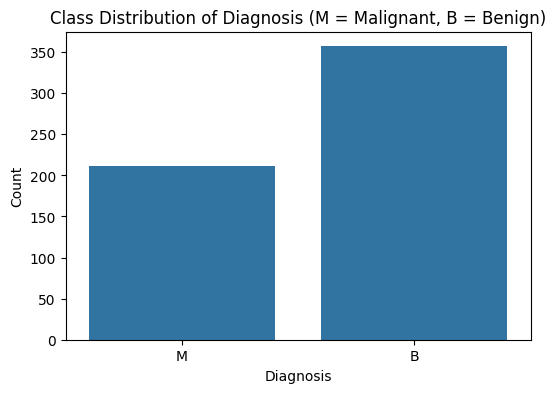

In [49]:
# Examine the class distribution of the target variable 'diagnosis'
print("Class Distribution of Diagnosis:\n", custom_df['diagnosis'].value_counts())

# Calculate the percentage of each class
class_percentages = custom_df['diagnosis'].value_counts(normalize=True) * 100
print("\nClass Distribution (Percentage):\n", class_percentages)

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=custom_df)
plt.title("Class Distribution of Diagnosis (M = Malignant, B = Benign)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

#### 2) Data Pre-processing

Drop irrelevant features and Encode labels

In [50]:
# Drop the 'id' column if it exists
if 'id' in custom_df.columns:
    custom_df = custom_df.drop('id', axis=1)
    print("Dropped 'id' column.")
else:
    print("No 'id' column found in the dataset.")

# Inspect the 'diagnosis' column before mapping
print("Unique values in 'diagnosis' before mapping:", custom_df['diagnosis'].unique())

Dropped 'id' column.
Unique values in 'diagnosis' before mapping: ['M' 'B']


In [51]:
# Remove any leading/trailing whitespace and convert to string for consistent handling
custom_df['diagnosis'] = custom_df['diagnosis'].astype(str).str.strip()

# Handle different possible formats and ensure conversion to integers
if set(custom_df['diagnosis'].unique()).issubset({'M', 'B'}):
    custom_df['diagnosis'] = custom_df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)
elif set(custom_df['diagnosis'].unique()).issubset({'malignant', 'benign'}):
    custom_df['diagnosis'] = custom_df['diagnosis'].map({'malignant': 1, 'benign': 0}).astype(int)
elif set(custom_df['diagnosis'].unique()).issubset({'1', '0'}):
    custom_df['diagnosis'] = pd.to_numeric(custom_df['diagnosis'], downcast='integer')
else:
    raise ValueError(f"Cannot map 'diagnosis' values: {custom_df['diagnosis'].unique()}. Please check the data.")

# Verify the mapping
print("Unique values in 'diagnosis' after mapping:", custom_df['diagnosis'].unique())
print("Data type of 'diagnosis':", custom_df['diagnosis'].dtype)

Unique values in 'diagnosis' after mapping: [1 0]
Data type of 'diagnosis': int64


In [52]:
# Verify the mapping
print("Unique values in 'diagnosis' after mapping:", custom_df['diagnosis'].unique())
print("Data type of 'diagnosis':", custom_df['diagnosis'].dtype)

Unique values in 'diagnosis' after mapping: [1 0]
Data type of 'diagnosis': int64


In [53]:
# Check for NaN values
if custom_df['diagnosis'].isnull().any():
    raise ValueError("NaN values found in 'diagnosis' after mapping. Please check the data.")

# Display the first few rows to confirm changes
print("First few rows after encoding 'diagnosis':\n", custom_df.head())

First few rows after encoding 'diagnosis':
    diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0

Normalize Features and Prepare Data
- normalize the features to the [0, 1] range, similar to how MNIST pixel values were normalized, and prepare X and y as NumPy arrays for training.

In [54]:
# Separate features (X) and labels (y)
X = custom_df.drop(columns=['diagnosis']).values  # 'id' already dropped
y = custom_df['diagnosis'].values

# Normalize features to [0, 1] range (like MNIST: X / 255)
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# Verify shapes and data
print("X Shape:", X.shape)  # Should be (569, 30)
print("y Shape:", y.shape)  # Should be (569,)
print("\nFirst 5 X samples (normalized):")
print(X[:5])
print("\nFirst 5 y labels:")
print(y[:5])

X Shape: (569, 30)
y Shape: (569,)

First 5 X samples (normalized):
[[0.52103744 0.0226581  0.54598853 0.36373277 0.59375282 0.7920373
  0.70313964 0.73111332 0.68636364 0.60551811 0.35614702 0.12046941
  0.3690336  0.27381126 0.15929565 0.35139844 0.13568182 0.30062512
  0.31164518 0.18304244 0.62077552 0.14152452 0.66831017 0.45069799
  0.60113584 0.61929156 0.56861022 0.91202749 0.59846245 0.41886396]
 [0.64314449 0.27257355 0.61578329 0.50159067 0.28987993 0.18176799
  0.20360825 0.34875746 0.37979798 0.14132266 0.15643672 0.08258929
  0.12444047 0.12565979 0.11938675 0.08132304 0.0469697  0.25383595
  0.08453875 0.0911101  0.60690146 0.30357143 0.53981772 0.43521431
  0.34755332 0.15456336 0.19297125 0.63917526 0.23358959 0.22287813]
 [0.60149557 0.3902604  0.59574321 0.44941676 0.51430893 0.4310165
  0.46251172 0.63568588 0.50959596 0.21124684 0.22962158 0.09430251
  0.18037035 0.16292179 0.15083115 0.2839547  0.09676768 0.38984656
  0.20569032 0.12700551 0.55638563 0.36007463 0.

#### Exploring Data: Visualization After Preprocessing

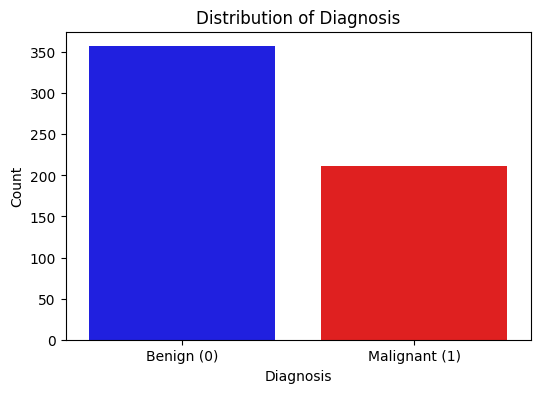

In [55]:
# Plot the distribution of diagnosis (now that it's encoded)
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', hue='diagnosis', data=custom_df, palette={0: 'blue', 1: 'red'}, legend=False)
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Benign (0)', 'Malignant (1)'])
plt.show()

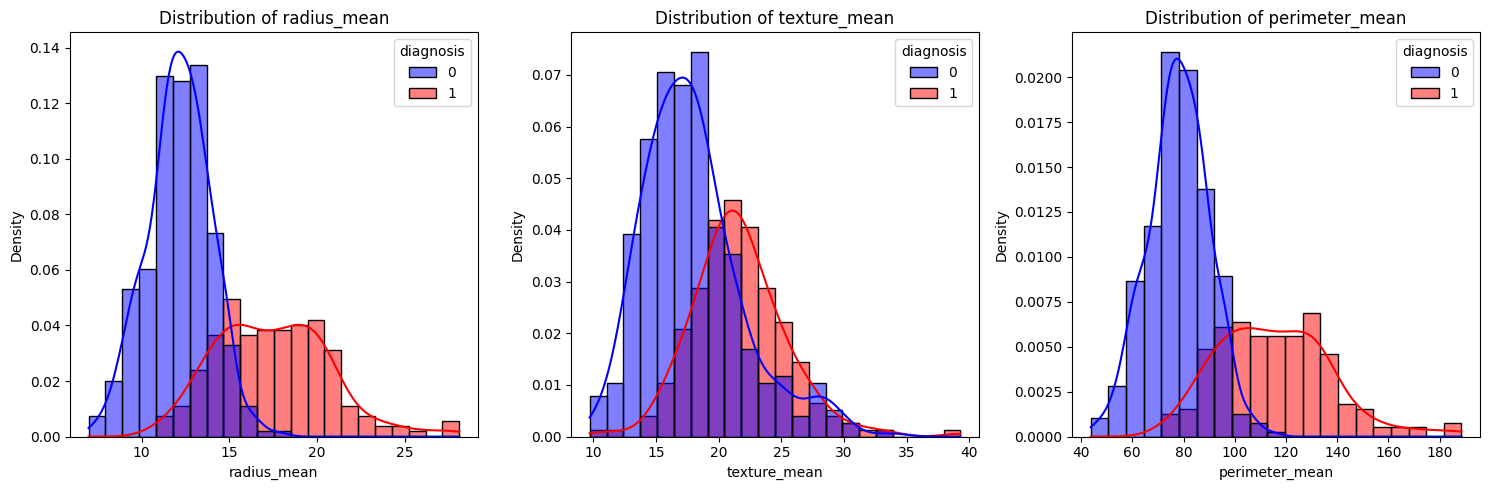

In [56]:
# Plot distributions of key features
features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean']
plt.figure(figsize=(15, 5))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.histplot(data=custom_df, x=feature, hue='diagnosis', kde=True, stat='density', palette={0: 'blue', 1: 'red'})
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
plt.tight_layout()
plt.show()

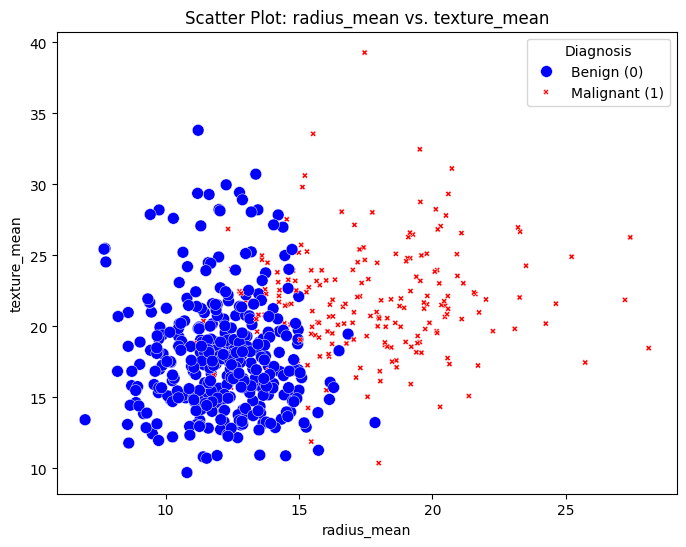

In [57]:
# Scatter plot between radius_mean and texture_mean
plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(
    data=custom_df, 
    x='radius_mean', 
    y='texture_mean', 
    hue='diagnosis', 
    style='diagnosis', 
    size='diagnosis',
    palette={0: 'blue', 1: 'red'}  # Benign (0) = blue, Malignant (1) = red
)
plt.title('Scatter Plot: radius_mean vs. texture_mean')
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles[:2], ['Benign (0)', 'Malignant (1)'], title='Diagnosis')
plt.show()

#### 2) Design the Neural NEtwork - Define Activation Functions
- Define Sigmoid and Softmax for hidden and output layers, respectively

In [58]:
def sigmoid(x):
    """Numerically stable sigmoid function."""
    x = np.clip(x, -500, 500)  # Avoid overflow
    return np.where(x >= 0,
                    1 / (1 + np.exp(-x)),
                    np.exp(x) / (1 + np.exp(x)))

def softmax(x):
    """Compute softmax probabilities."""
    x_shifted = x - np.max(x)  # Subtract max for numerical stability
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x)

# Test the functions
print("sigmoid(3) =", sigmoid(3))
print("sigmoid([3, 4, 5]) =", sigmoid(np.array([3, 4, 5])))
print("softmax([3, 4, 5]) =", softmax(np.array([3, 4, 5])))

sigmoid(3) = 0.9525741268224334
sigmoid([3, 4, 5]) = [0.95257413 0.98201379 0.99330715]
softmax([3, 4, 5]) = [0.09003057 0.24472847 0.66524096]


Define One-Hot Encoding and Loss Function

In [59]:
def one_hot_encode(x):
    """Convert integer labels to one-hot encoding."""
    result = np.zeros((len(x), 2))  # 2 classes (0 and 1)
    for i in range(len(x)):
        result[i, int(x[i])] = 1
    return result

def cross_entropy_loss(y, y_pred):
    """Compute cross-entropy loss."""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)  # Avoid log(0)
    return -np.sum(y * np.log(y_pred))

# Test the functions
y_sample = np.array([1, 0, 1, 0])
y_one_hot = one_hot_encode(y_sample)
y_pred_sample = np.array([[0.1, 0.9], [0.8, 0.2], [0.3, 0.7], [0.6, 0.4]])
print("One-hot encoding of", y_sample, ":\n", y_one_hot)
print("Cross-entropy loss:", cross_entropy_loss(y_one_hot, y_pred_sample))

One-hot encoding of [1 0 1 0] :
 [[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
Cross-entropy loss: 1.1960046346767592


Initialize Weignts and Biases
- Weight and biases for a 30-16-16-2 neural network, matching the architecture to the 30 input features and 2 output classes

In [60]:
rng = np.random.default_rng(42)

# Initialize weights: [layer1: 16x30, layer2: 16x16, output: 2x16]
weights = [
    rng.normal(0, 1, (16, 30)),  # First layer: 16 nodes x 30 inputs
    rng.normal(0, 1, (16, 16)),   # Second layer: 16 nodes x 16 previous nodes
    rng.normal(0, 1, (2, 16))     # Output layer: 2 nodes x 16 previous nodes
]

# Initialize biases
biases = [
    np.zeros(16),  # First layer
    np.zeros(16),  # Second layer
    np.zeros(2)    # Output layer
]

# Verify shapes
print("Weights shapes:", [w.shape for w in weights])
print("Biases shapes:", [b.shape for b in biases])

Weights shapes: [(16, 30), (16, 16), (2, 16)]
Biases shapes: [(16,), (16,), (2,)]


Define Feed Forward Function
- perform the forward pass for a single sample and a batch of samples, computing predictions through the 30-16-16-2 network.

In [61]:
def feed_forward_sample(sample, weights, biases):
    """Feed forward a single sample through the neural network."""
    # Layer 1
    z1 = np.dot(weights[0], sample) + biases[0]
    a1 = sigmoid(z1)
    
    # Layer 2
    z2 = np.dot(weights[1], a1) + biases[1]
    a2 = sigmoid(z2)
    
    # Output layer
    z3 = np.dot(weights[2], a2) + biases[2]
    a3 = softmax(z3)
    
    return a3

def feed_forward_batch(X, weights, biases):
    """Feed forward a batch of samples."""
    # Layer 1
    z1 = np.dot(X, weights[0].T) + biases[0]
    a1 = sigmoid(z1)
    
    # Layer 2
    z2 = np.dot(a1, weights[1].T) + biases[1]
    a2 = sigmoid(z2)
    
    # Output layer
    z3 = np.dot(a2, weights[2].T) + biases[2]
    a3 = np.apply_along_axis(softmax, 1, z3)
    
    return a3

# Define cost and accuracy functions
def calculate_cost(y, y_pred):
    """Calculate the average loss over a series of predictions."""
    losses = [cross_entropy_loss(one_hot_encode([y[i]]), y_pred[i]) for i in range(len(y))]
    return np.mean(losses)

def calculate_accuracy(y, y_pred):
    """Calculate accuracy."""
    # Get predicted classes (shape: (n_samples,))
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # Get true classes (shape: (n_samples,))
    y_true_classes = y.astype(int)
    
    # Compute accuracy: proportion of correct predictions
    correct_predictions = np.sum(y_true_classes == y_pred_classes)
    accuracy = correct_predictions / len(y) * 100
    return accuracy

# Test the functions
X_test = X[:1000]  # Use all samples (569 < 1000)
y_test = y[:1000]
y_pred = feed_forward_batch(X_test, weights, biases)
print("Average loss:", calculate_cost(y_test, y_pred) * 2.0)
print("Accuracy:", calculate_accuracy(y_test, y_pred))

Average loss: 3.1630125000308276
Accuracy: 37.258347978910365


#### 3) Train the Neural Network
- Define the backpropagation function (including the derivative of sigmoid) and train the neural network for 10,000 iterations, monitoring the loss and accuracy.

In [62]:
def dsigmoid(x):
    """Derivative of sigmoid."""
    return sigmoid(x) * (1 - sigmoid(x))

def train_nn(X, y, weights, biases):
    """Train the neural network with backpropagation."""
    learning_rate = 0.01
    
    # Pick a random sample
    i = np.random.randint(X.shape[0])
    sample = X[i]
    
    # Feed forward
    z0 = np.matmul(weights[0], sample) + biases[0]
    a0 = sigmoid(z0)
    z1 = np.matmul(weights[1], a0) + biases[1]
    a1 = sigmoid(z1)
    z2 = np.matmul(weights[2], a1) + biases[2]
    a2 = softmax(z2)
    
    # Backprop
    y_hot = one_hot_encode([y[i]])[0]
    a2 = a2  # Softmax gradient is handled by cross-entropy
    a1 = a1
    a0 = a0
    input_layer = sample
    
    # Last layer
    weights[2] -= np.matmul((a2 - y_hot).reshape(-1, 1), a1.reshape(1, -1)) * learning_rate
    biases[2] -= (a2 - y_hot).flatten() * learning_rate
    
    # Second hidden layer
    dcda = np.matmul(weights[2].T, (a2 - y_hot))
    activation_gradients = dcda * dsigmoid(z1)
    weights[1] -= np.matmul(activation_gradients.reshape(-1, 1), a0.reshape(1, -1)) * learning_rate
    biases[1] -= activation_gradients * learning_rate
    
    # First hidden layer
    dcda = np.matmul(weights[1].T, activation_gradients)
    activation_gradients = dcda * dsigmoid(z0)
    weights[0] -= np.matmul(activation_gradients.reshape(-1, 1), input_layer.reshape(1, -1)) * learning_rate
    biases[0] -= activation_gradients * learning_rate
    
    return weights, biases

# Training loop
for i in range(10000):
    weights, biases = train_nn(X, y, weights, biases)
    if i % 1000 == 0:
        y_pred = feed_forward_batch(X, weights, biases)
        print(f"Iteration {i}, Average loss: {calculate_cost(y, y_pred) * 2.0:.4f}")
        print(f"Accuracy: {calculate_accuracy(y, y_pred):.2f}%")

Iteration 0, Average loss: 3.0068
Accuracy: 37.26%
Iteration 1000, Average loss: 0.7966
Accuracy: 85.06%
Iteration 2000, Average loss: 0.5219
Accuracy: 93.85%
Iteration 3000, Average loss: 0.4054
Accuracy: 93.50%
Iteration 4000, Average loss: 0.3342
Accuracy: 95.25%
Iteration 5000, Average loss: 0.2950
Accuracy: 95.61%
Iteration 6000, Average loss: 0.2802
Accuracy: 95.61%
Iteration 7000, Average loss: 0.2439
Accuracy: 96.31%
Iteration 8000, Average loss: 0.2304
Accuracy: 96.84%
Iteration 9000, Average loss: 0.2102
Accuracy: 97.01%


#### 4) Evaluate the Model and Interpret Results
- Evaluating the final  model by computing the accuracy and loss on the entire dataset
- Interpret the results of model performance

In [63]:
# Final evaluation
y_pred = feed_forward_batch(X, weights, biases)
final_loss = calculate_cost(y, y_pred) * 2.0
final_accuracy = calculate_accuracy(y, y_pred)

print(f"Final Average Loss: {final_loss:.4f}")
print(f"Final Accuracy: {final_accuracy:.2f}%")

# Interpretation
print("\nInterpretation of Results:")
print("The model was trained on the Breast Cancer dataset with 569 samples and 30 features.")
print(f"After 10,000 iterations, the model achieved an accuracy of {final_accuracy:.2f}%.")
print(f"The final loss is {final_loss:.4f}, indicating the model's fit to the data.")
print("Given that the dataset has a class imbalance (62.7% Benign, 37.3% Malignant), an accuracy above 62.7% suggests the model is learning meaningful patterns.")
print("However, since we trained and evaluated on the same data, the model may be overfitting. In a real-world scenario, we would split the data into training and test sets to better assess generalization.")

Final Average Loss: 0.2056
Final Accuracy: 97.36%

Interpretation of Results:
The model was trained on the Breast Cancer dataset with 569 samples and 30 features.
After 10,000 iterations, the model achieved an accuracy of 97.36%.
The final loss is 0.2056, indicating the model's fit to the data.
Given that the dataset has a class imbalance (62.7% Benign, 37.3% Malignant), an accuracy above 62.7% suggests the model is learning meaningful patterns.
However, since we trained and evaluated on the same data, the model may be overfitting. In a real-world scenario, we would split the data into training and test sets to better assess generalization.
